# Netflix Dataset Analysis

## Capstone Project 1

### Project Objective

This project analyzes the Netflix content library to identify trends and patterns in content type, release years, countries, genres, ratings, movie runtimes, and directors.

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

### Dataset

The analysis uses the Netflix Movies and TV Shows dataset containing information about titles available on Netflix, including content type, title, director, cast, country, release year, rating, duration, genres, and description.

## Project Overview

The objective of this analysis is to explore Netflix's content library and uncover meaningful patterns that could help understand the platform's content strategy.

The analysis focuses on:

1. Content distribution between Movies and TV Shows
2. Content release trends over time
3. Geographic distribution of Netflix titles
4. Popular genres and categories
5. Content ratings
6. Movie runtime distribution
7. Directors with the highest number of titles

The project follows a typical data-analysis workflow:

**Data Loading → Data Cleaning → Exploratory Data Analysis → Visualization → Key Findings**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv("netflix.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df_clean = df.copy()

In [11]:
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [12]:
df_clean["director"] = df_clean["director"].fillna("Unknown")
df_clean["cast"] = df_clean["cast"].fillna("Unknown")
df_clean["country"] = df_clean["country"].fillna("Unknown")
df_clean["rating"] = df_clean["rating"].fillna("Unknown")

In [13]:
df_clean["date_added"] = pd.to_datetime(df_clean["date_added"], errors="coerce")

In [14]:
df_clean["date_added"].dtype

dtype('<M8[ns]')

In [15]:
df_clean.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64

In [16]:
df[df["date_added"].isna()]["date_added"]

6066    NaN
6174    NaN
6795    NaN
6806    NaN
6901    NaN
7196    NaN
7254    NaN
7406    NaN
7847    NaN
8182    NaN
Name: date_added, dtype: object

In [17]:
df.loc[df_clean["date_added"].isna(), ["show_id", "title", "date_added"]]

,show_id,title,date_added
6066,s6067,A Young Doctor's Notebook and Other Stories,NaN
6079,s6080,Abnormal Summit,"August 4, 2017"
6174,s6175,Anthony Bourdain: Parts Unknown,NaN
6177,s6178,忍者ハットリくん,"December 23, 2018"
6213,s6214,Bad Education,"December 15, 2018"
...,...,...,...
8539,s8540,The Tudors,"January 8, 2018"
8557,s8558,The West Wing,"December 25, 2015"
8684,s8685,Vroomiz,"August 1, 2017"
8712,s8713,Weird Wonders of the World,"March 31, 2017"


In [18]:
df_clean[df_clean["duration"].isna()][["show_id", "title", "type", "duration"]]

,show_id,title,type,duration
5541,s5542,Louis C.K. 2017,Movie,NaN
5794,s5795,Louis C.K.: Hilarious,Movie,NaN
5813,s5814,Louis C.K.: Live at the Comedy Store,Movie,NaN


In [19]:
df.loc[df_clean["date_added"].isna(), "date_added"].value_counts(dropna=False)

date_added
NaN                    10
 July 1, 2017           4
 August 4, 2017         3
 November 1, 2017       3
 January 1, 2018        3
                       ..
 April 17, 2016         1
 March 22, 2015         1
 September 16, 2018     1
 April 16, 2019         1
 March 31, 2017         1
Name: count, Length: 69, dtype: int64

In [20]:
df.loc[df_clean["date_added"].isna(), "date_added"].value_counts(dropna=False)

date_added
NaN                    10
 July 1, 2017           4
 August 4, 2017         3
 November 1, 2017       3
 January 1, 2018        3
                       ..
 April 17, 2016         1
 March 22, 2015         1
 September 16, 2018     1
 April 16, 2019         1
 March 31, 2017         1
Name: count, Length: 69, dtype: int64

In [21]:
df_clean["date_added"] = df["date_added"].str.strip()
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"],
    errors="coerce"
)

In [22]:
df_clean["date_added"] = df["date_added"].str.strip()
df_clean["date_added"] = pd.to_datetime(df_clean["date_added"], errors="coerce")

In [23]:
df_clean.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64

In [24]:
df_clean["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

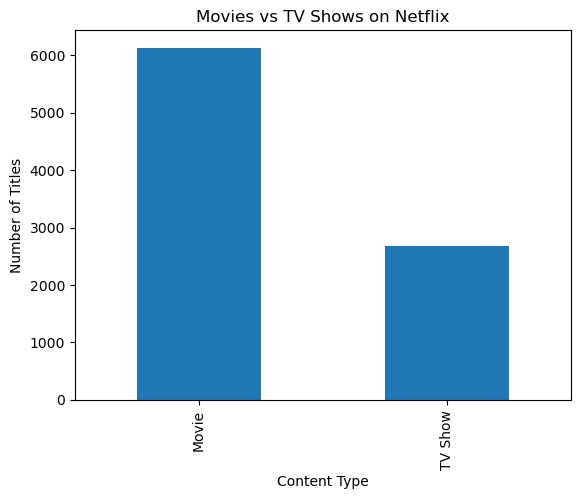

In [25]:
df_clean["type"].value_counts().plot(
    kind="bar",
    title="Movies vs TV Shows on Netflix"
)

plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

### Key Finding 1

Movies dominate the Netflix dataset, with 6,131 movies compared with
2,676 TV shows. Movies account for approximately 69.6% of the total
titles, while TV shows account for approximately 30.4%.

In [26]:
df_clean["release_year"].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

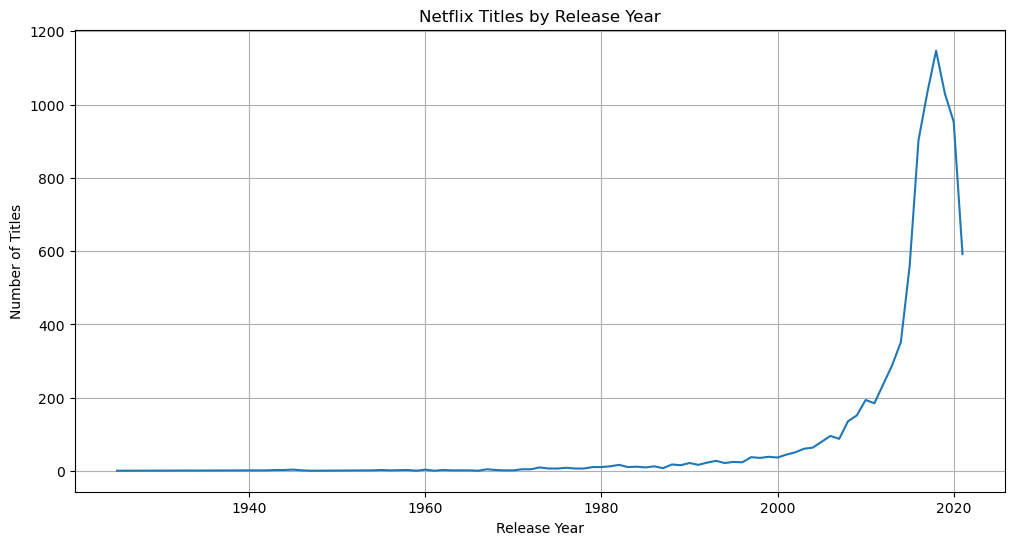

In [27]:
release_year_counts = df_clean["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(release_year_counts.index, release_year_counts.values)
plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

### Key Finding 2

The Netflix dataset is heavily concentrated around content released in
the 2010s. The year 2018 has the highest number of titles, with 1,147
titles, indicating a strong representation of relatively recent content
in the dataset.

In [28]:
df_clean["country"].value_counts().head(10)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [29]:
country_data = df_clean["country"].str.split(", ")

In [30]:
country_counts = country_data.explode().value_counts()

In [31]:
country_counts.head(10)

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

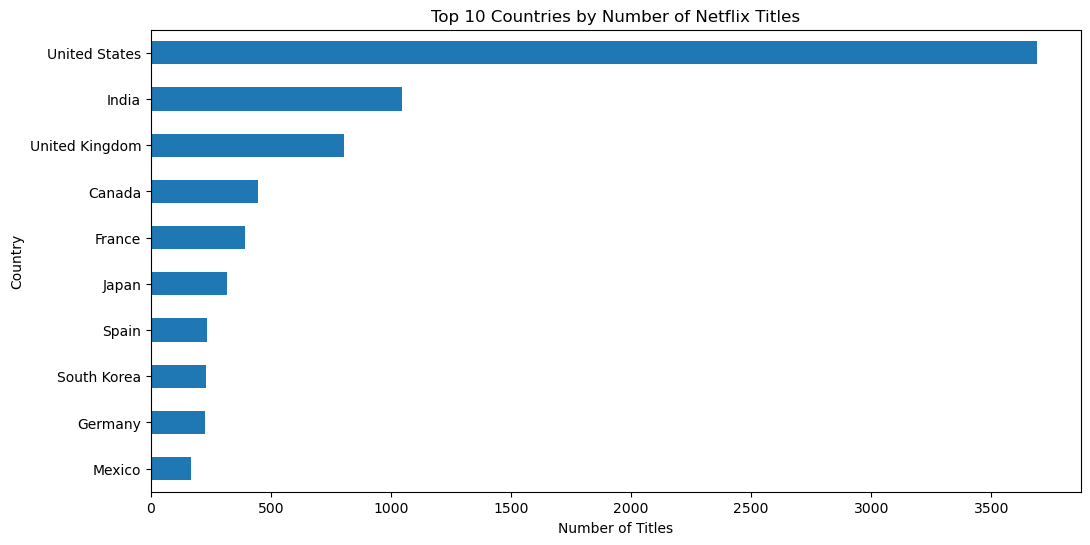

In [32]:
top_countries = country_counts.drop("Unknown").head(10)

plt.figure(figsize=(12, 6))
top_countries.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

### Key Finding 3

The United States is the most represented country in the Netflix
dataset, with 3,689 title associations, followed by India with 1,046
and the United Kingdom with 804.

This indicates strong representation of content associated with the
United States and other major international content markets.

> Note: Some titles are associated with multiple countries, so country
counts can exceed the total number of Netflix titles.

In [33]:
genre_data = df_clean["listed_in"].str.split(", ")

In [34]:
genre_counts = genre_data.explode().value_counts()

In [35]:
genre_counts.head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

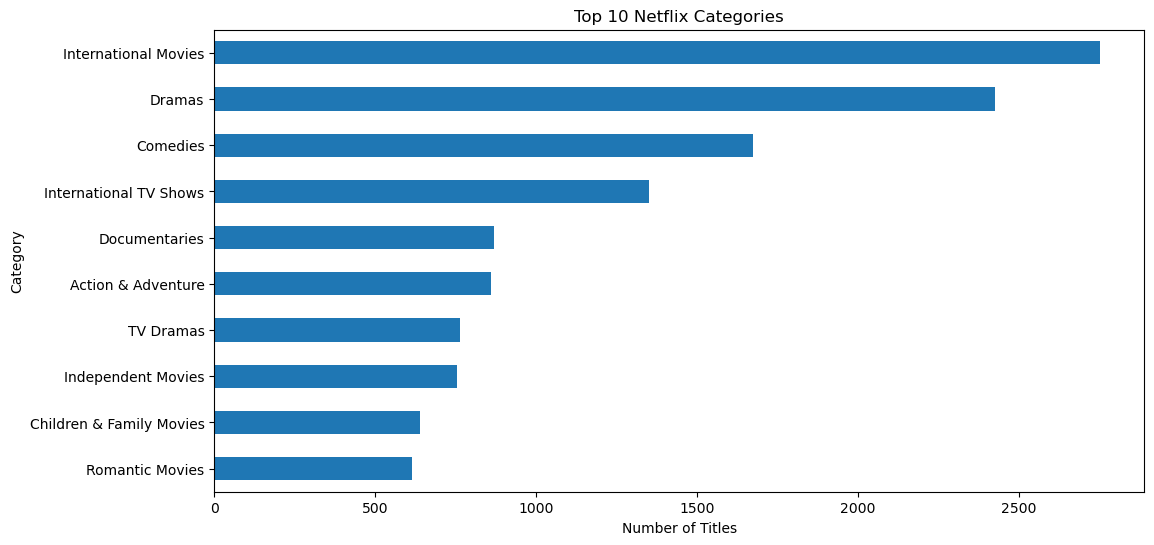

In [36]:
top_genres = genre_counts.head(10)

plt.figure(figsize=(12, 6))
top_genres.sort_values().plot(kind="barh")

plt.title("Top 10 Netflix Categories")
plt.xlabel("Number of Titles")
plt.ylabel("Category")

plt.show()

### Key Finding 4

International Movies are the most frequently represented category in
the Netflix dataset, with 2,752 title associations, followed by Dramas
with 2,427 and Comedies with 1,674.

This indicates a strong presence of international and drama-oriented
content within the Netflix catalog.

> Note: A single title can belong to multiple categories, so category
counts represent title-category associations rather than unique titles.

In [37]:
df_clean["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [38]:
# Find rows where rating contains a duration
duration_mask = df_clean["rating"].str.contains("min", na=False)

# Move those values from rating to duration
df_clean.loc[duration_mask, "duration"] = df_clean.loc[duration_mask, "rating"]

# Replace the incorrect rating values with Unknown
df_clean.loc[duration_mask, "rating"] = "Unknown"

In [39]:
df_clean[["title", "rating", "duration"]].loc[duration_mask]

,title,rating,duration
5541,Louis C.K. 2017,Unknown,74 min
5794,Louis C.K.: Hilarious,Unknown,84 min
5813,Louis C.K.: Live at the Comedy Store,Unknown,66 min


In [40]:
df_clean["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

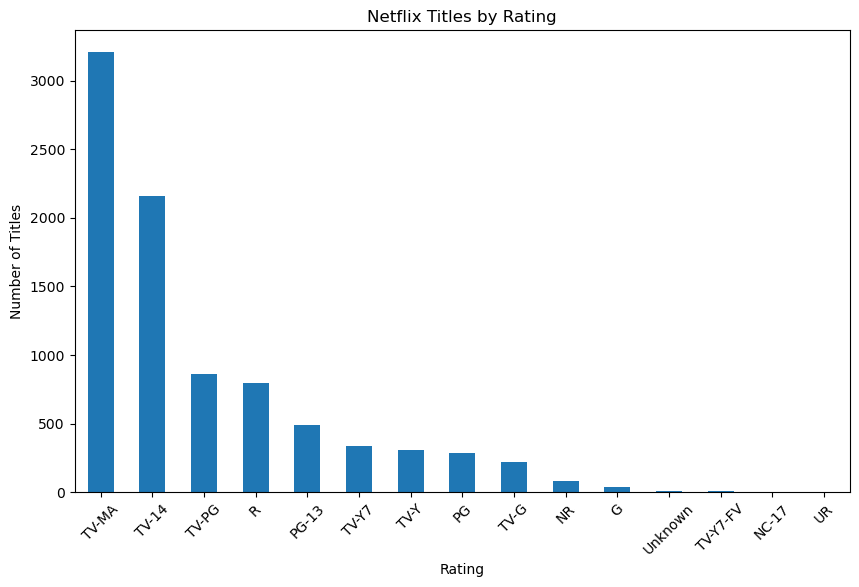

In [41]:
rating_counts = df_clean["rating"].value_counts()

plt.figure(figsize=(10, 6))
rating_counts.plot(kind="bar")

plt.title("Netflix Titles by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

### Key Finding 5

TV-MA is the most common rating in the Netflix dataset, with 3,207
titles, followed by TV-14 with 2,160 titles. This indicates that a
large proportion of the catalog is targeted toward mature and
teen audiences.

The distribution also includes a wide range of ratings, from
children's categories such as TV-Y and TV-G to mature ratings such
as TV-MA and NC-17.

In [42]:
type_year = df_clean.groupby(["release_year", "type"]).size().unstack(fill_value=0)

type_year.tail(10)

type,Movie,TV Show
release_year,,
2012,173,64
2013,225,63
2014,264,88
2015,398,162
2016,658,244
2017,767,265
2018,767,380
2019,633,397
2020,517,436


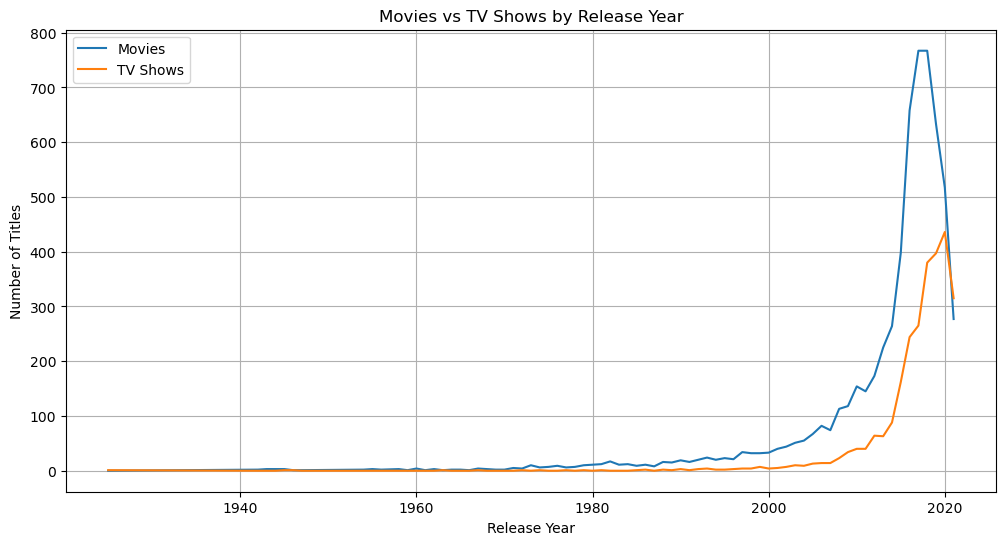

In [43]:
plt.figure(figsize=(12, 6))

plt.plot(type_year.index, type_year["Movie"], label="Movies")
plt.plot(type_year.index, type_year["TV Show"], label="TV Shows")

plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.grid(True)

plt.show()

### Key Finding 6

The number of both Movies and TV Shows increased substantially in the
later years of the dataset. Movies generally remained more numerous than
TV Shows, with a particularly strong increase in movie releases during
the mid-to-late 2010s.

TV Shows also experienced significant growth during this period,
indicating an expanding representation of episodic content in the
Netflix dataset.

Note: The decline observed in 2021 should be interpreted cautiously,
as recent-year data may be incomplete.

In [44]:
df_clean["date_added"].dt.year.value_counts().sort_index()

date_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

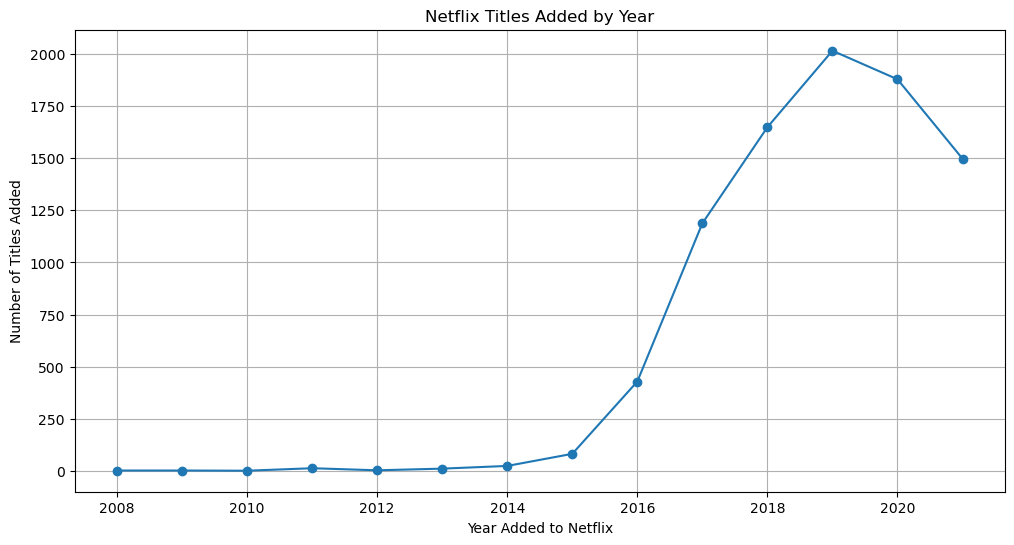

In [45]:
additions_by_year = df_clean["date_added"].dt.year.value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(additions_by_year.index, additions_by_year.values, marker="o")

plt.title("Netflix Titles Added by Year")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Number of Titles Added")
plt.grid(True)

plt.show()

### Key Finding 7

Netflix title additions increased sharply from 2015 onward, reaching
their highest level in 2019. The number of titles added remained high
in 2020 before declining in 2021.

This indicates that the Netflix dataset reflects a period of rapid
content expansion, particularly between 2016 and 2020.

Note: The analysis is based on the `date_added` values available in
the dataset. The 10 records with missing `date_added` values are not
included in this analysis.

In [46]:
movie_data = df_clean[df_clean["type"] == "Movie"].copy()

movie_data["duration_minutes"] = (
    movie_data["duration"]
    .str.replace(" min", "", regex=False)
    .astype(float)
)

movie_data["duration_minutes"].describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

In [48]:
# Select movies from the cleaned dataset
movies = df_clean[df_clean["type"] == "Movie"].copy()

# Convert duration from text like "90 min" to a number
movies["duration_minutes"] = movies["duration"].str.replace(" min", "", regex=False).astype(float)

# Calculate average and median
average_runtime = movies["duration_minutes"].mean()
median_runtime = movies["duration_minutes"].median()

print("Average Movie Runtime:", round(average_runtime, 2), "minutes")
print("Median Movie Runtime:", median_runtime, "minutes")

Average Movie Runtime: 99.56 minutes
Median Movie Runtime: 98.0 minutes


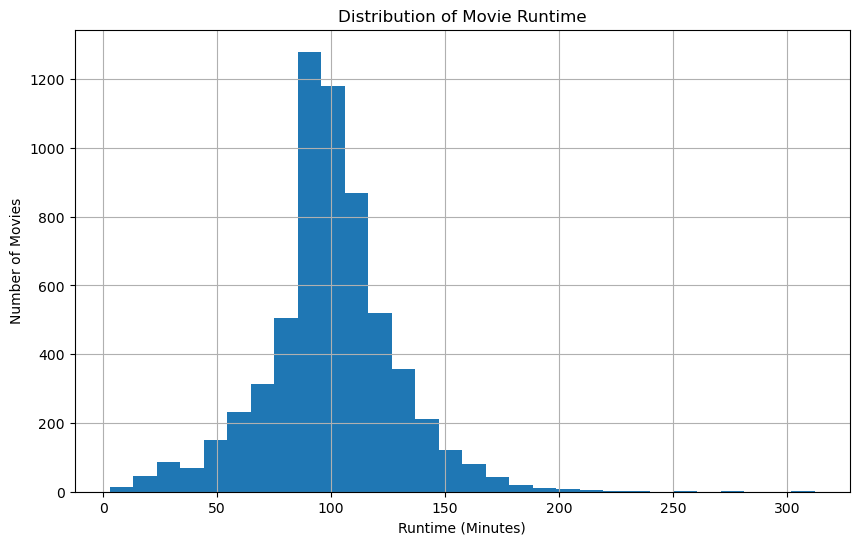

In [49]:
plt.figure(figsize=(10, 6))

plt.hist(movies["duration_minutes"].dropna(), bins=30)

plt.title("Distribution of Movie Runtime")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("Number of Movies")

plt.grid(True)
plt.show()

## Key Finding 8

The average movie runtime on Netflix is approximately 99.6 minutes, while the median runtime is 98 minutes. This shows that a typical Netflix movie in the dataset is around 1 hour and 40 minutes long.

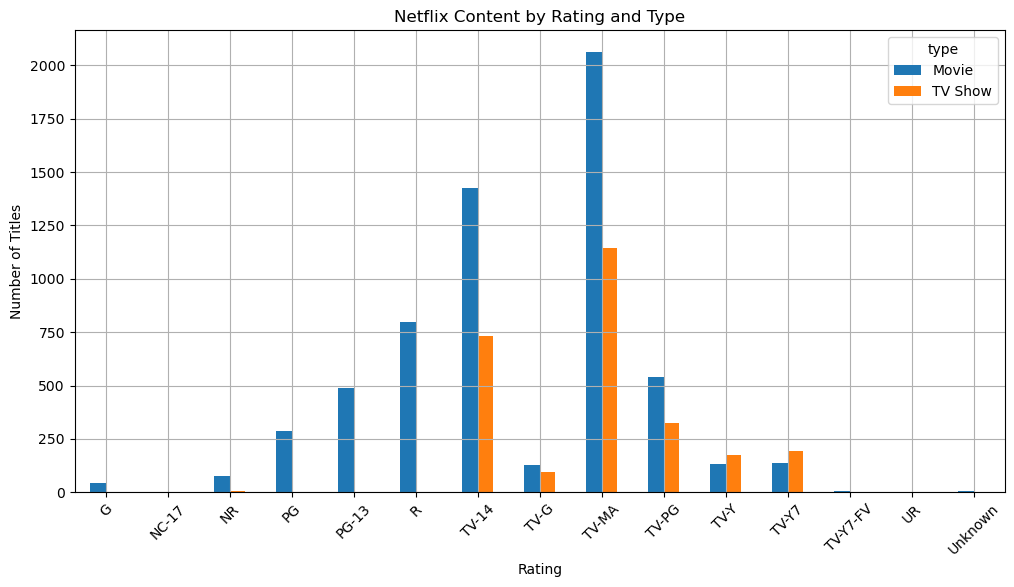

In [50]:
rating_type = pd.crosstab(df_clean["rating"], df_clean["type"])

rating_type.plot(kind="bar", figsize=(12, 6))

plt.title("Netflix Content by Rating and Type")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

## Key Finding 9

TV-MA and TV-14 are the most common ratings in the Netflix dataset. The distribution also shows that Movies make up a larger share of several ratings, while TV Shows are strongly represented in TV-specific ratings. This highlights Netflix's significant focus on mature and teen-oriented content.

In [51]:
top_directors = (
    df_clean[df_clean["director"] != "Unknown"]["director"]
    .value_counts()
    .head(10)
)

top_directors

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

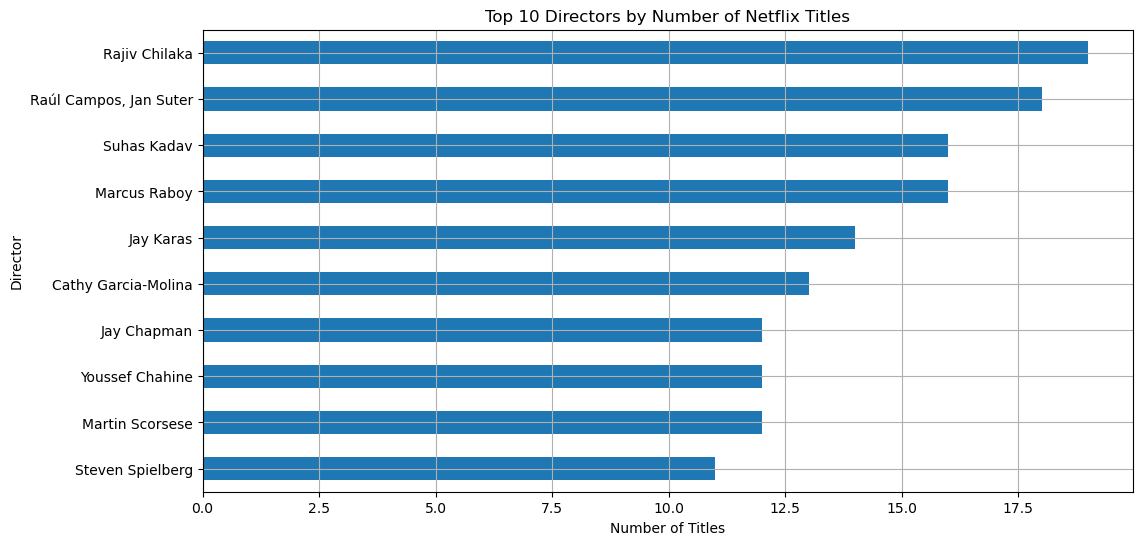

In [52]:
plt.figure(figsize=(12, 6))

top_directors.sort_values().plot(kind="barh")

plt.title("Top 10 Directors by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.grid(True)
plt.show()

## Key Finding 10

Rajiv Chilaka has the highest number of titles in the Netflix dataset with 19 titles, followed by Raúl Campos and Jan Suter with 18 titles. The top 10 directors have between 11 and 19 titles each, showing that Netflix's content library includes contributions from a diverse group of recurring directors.

# Conclusion

The analysis of the Netflix dataset provides several insights into the
platform's content library.

Movies represent the majority of titles, accounting for approximately
69.6% of the dataset, while TV Shows account for approximately 30.4%.
The dataset is also strongly concentrated around content released in
the 2010s, with 2018 having the highest number of titles.

The United States is the most represented country, followed by India
and the United Kingdom. International Movies, Dramas, and Comedies are
among the most common content categories.

TV-MA is the most common content rating, indicating a strong
representation of mature-oriented content. The average movie runtime
is approximately 99.6 minutes, with a median of 98 minutes.

Overall, the analysis demonstrates how Python-based data cleaning,
exploratory data analysis, and visualization can be used to identify
meaningful patterns in a large content dataset.

# Skills Demonstrated

- Python programming
- Pandas
- NumPy
- Data cleaning and preprocessing
- Missing-value handling
- Duplicate detection
- Data transformation
- Exploratory Data Analysis (EDA)
- Grouping and aggregation
- Multi-value categorical data analysis
- Data visualization
- Matplotlib
- Seaborn
- Analytical thinking
- Business insight generation

# Project Summary

### Dataset
Netflix Movies and TV Shows Dataset

### Records Analyzed
8,807 titles

### Main Tools
Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

### Analysis Areas
- Content type
- Release-year trends
- Countries
- Genres
- Ratings
- Movie runtimes
- Directors

### Outcome
The project demonstrates an end-to-end exploratory data analysis
workflow, from data cleaning and validation to visualization and
insight generation.